# Влияние социальных факторов на использование личных местоимений в блогах

In [ ]:
# 1. Установка и загрузка пакетов
if (!require("tidyverse")) install.packages("tidyverse")
if (!require("DescTools")) install.packages("DescTools")
if (!require("effsize")) install.packages("effsize")

library(tidyverse)
library(DescTools)
library(effsize)

In [ ]:
# 2. Чтение данных
data <- read_csv("blogtext.csv", show_col_types = FALSE) |>
  filter(!is.na(text), text != "", nchar(trimws(text)) > 0)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


In [ ]:
# 3. Подсчёт личных местоимений
pronouns <- c("i", "me", "my", "mine", "myself",
              "we", "us", "our", "ours", "ourselves")

count_pronouns <- function(text) {
  words <- strsplit(tolower(as.character(text)), "\\W+")[[1]]
  sum(words %in% pronouns)
}

data <- data |>
  mutate(
    total_words = map_int(text, ~ length(strsplit(tolower(as.character(.x)), "\\W+")[[1]])),
    pronoun_count = map_int(text, count_pronouns),
    freq_per_1000 = pronoun_count / total_words * 1000
  )

In [ ]:
# 4. Создание категориальных переменных
data <- data |>
  mutate(
    age_group = case_when(
      age <= 17 ~ "Teen",
      age <= 25 ~ "Young",
      age <= 40 ~ "Adult",
      TRUE ~ "Senior"
    ),
    gender = as.factor(gender),
    age_group = as.factor(age_group),
    sign = as.factor(sign)
  )

In [ ]:
# 5. Описательная статистика по каждому фактору
summarize_by_group <- function(data, group_var, target_var = "freq_per_1000") {
  data |>
    group_by(!!sym(group_var)) |>
    summarise(
      n = n(),
      mean = mean(!!sym(target_var), na.rm = TRUE),
      sd = sd(!!sym(target_var), na.rm = TRUE),
      median = median(!!sym(target_var), na.rm = TRUE),
      min = min(!!sym(target_var), na.rm = TRUE),
      max = max(!!sym(target_var), na.rm = TRUE)
    )
}

cat("\n=== Статистика по полу ===\n")
print(summarize_by_group(data, "gender"))

cat("\n=== Статистика по возрастным группам ===\n")
print(summarize_by_group(data, "age_group"))

cat("\n=== Статистика по знаку зодиака ===\n")
print(summarize_by_group(data, "sign"))


=== Статистика по полу ===
# A tibble: 2 × 7
  gender      n  mean    sd median   min   max
  <fct>   <int> <dbl> <dbl>  <dbl> <dbl> <dbl>
1 female 334701  69.4  46.9   71.4     0  1000
2 male   343498  55.8  45.1   54.0     0  1000

=== Статистика по возрастным группам ===
# A tibble: 4 × 7
  age_group      n  mean    sd median   min   max
  <fct>      <int> <dbl> <dbl>  <dbl> <dbl> <dbl>
1 Adult     198486  54.3  44.6   52.6     0  1000
2 Senior     25809  46.6  42.0   41.9     0  1000
3 Teen      234904  71.8  47.6   73.0     0  1000
4 Young     219000  61.8  45.4   62.5     0  1000

=== Статистика по знаку зодиака ===
# A tibble: 12 × 7
   sign            n  mean    sd median   min   max
   <fct>       <int> <dbl> <dbl>  <dbl> <dbl> <dbl>
 1 Aquarius    49467  61.9  46.3   62.1     0 1000 
 2 Aries       64805  61.6  48.3   61.5     0 1000 
 3 Cancer      64744  59.5  45.7   59.3     0  667.
 4 Capricorn   49007  63.0  45.5   64.1     0 1000 
 5 Gemini      51717  64.4  47.2   65.

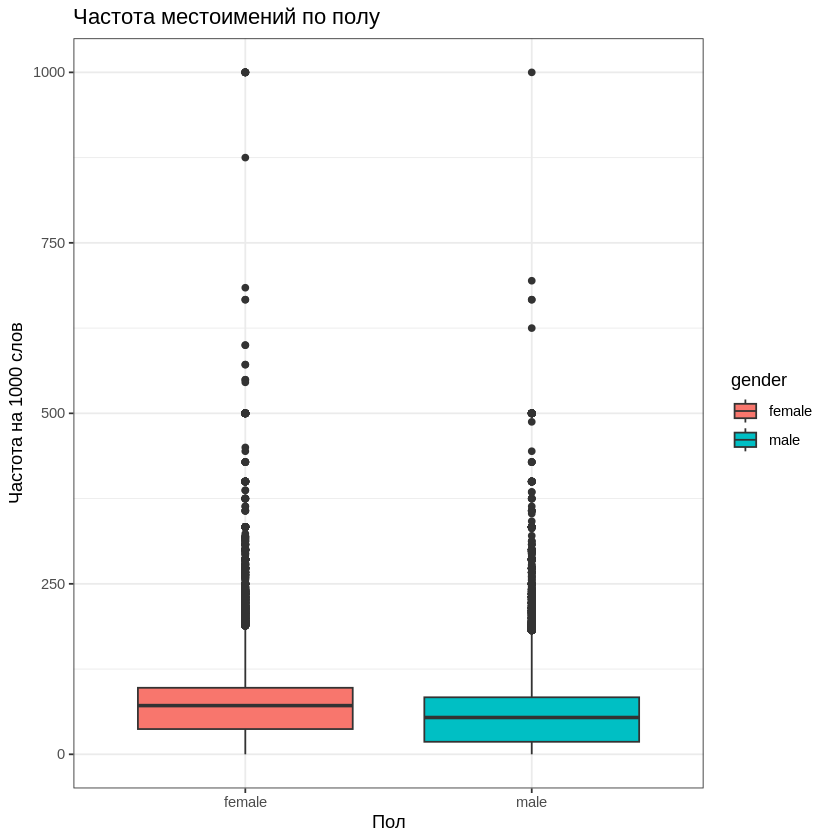

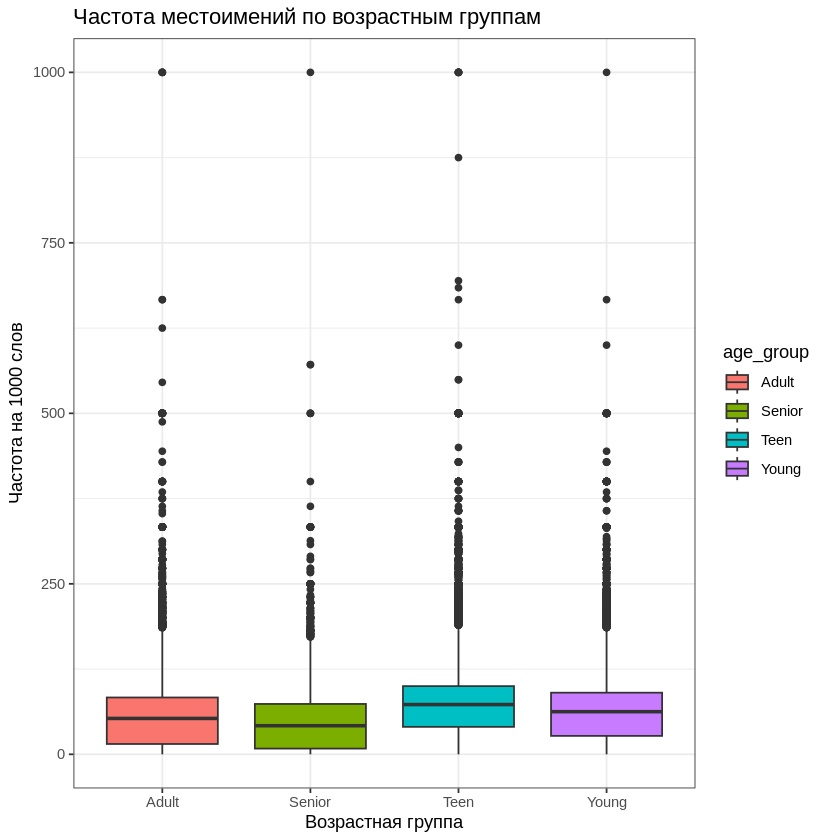

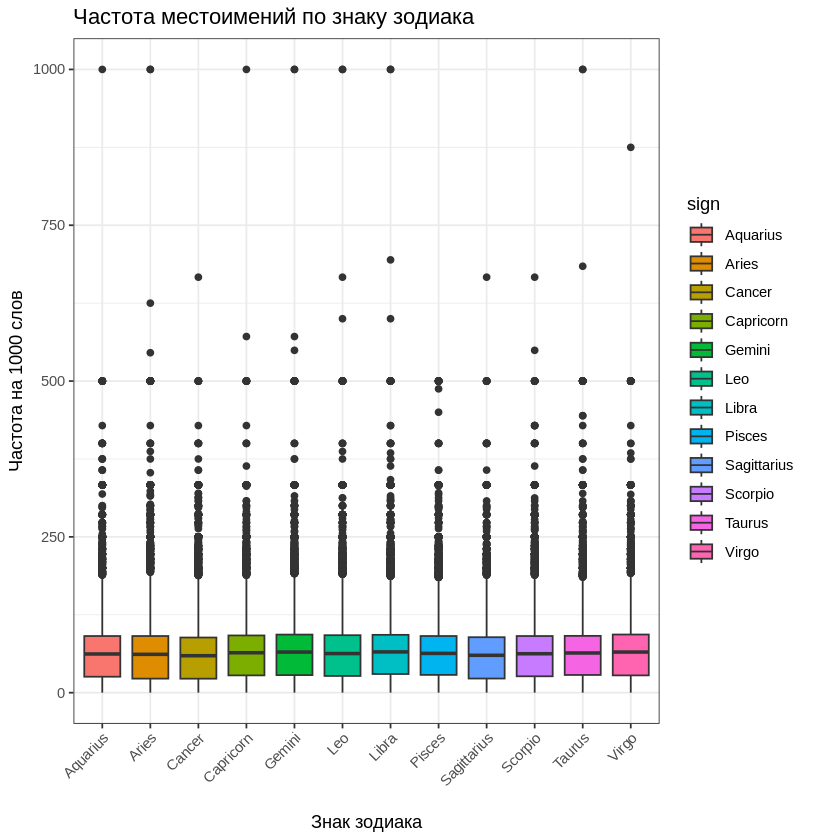

In [ ]:
# 6. Визуализация распределений (боксплоты и плотность)
p_gender <- ggplot(data, aes(x = gender, y = freq_per_1000, fill = gender)) +
  geom_boxplot() +
  labs(title = "Частота местоимений по полу", x = "Пол", y = "Частота на 1000 слов") +
  theme_bw()

p_age <- ggplot(data, aes(x = age_group, y = freq_per_1000, fill = age_group)) +
  geom_boxplot() +
  labs(title = "Частота местоимений по возрастным группам", x = "Возрастная группа", y = "Частота на 1000 слов") +
  theme_bw()

p_sign <- ggplot(data, aes(x = sign, y = freq_per_1000, fill = sign)) +
  geom_boxplot() +
  labs(title = "Частота местоимений по знаку зодиака", x = "Знак зодиака", y = "Частота на 1000 слов") +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

print(p_gender)
print(p_age)
print(p_sign)

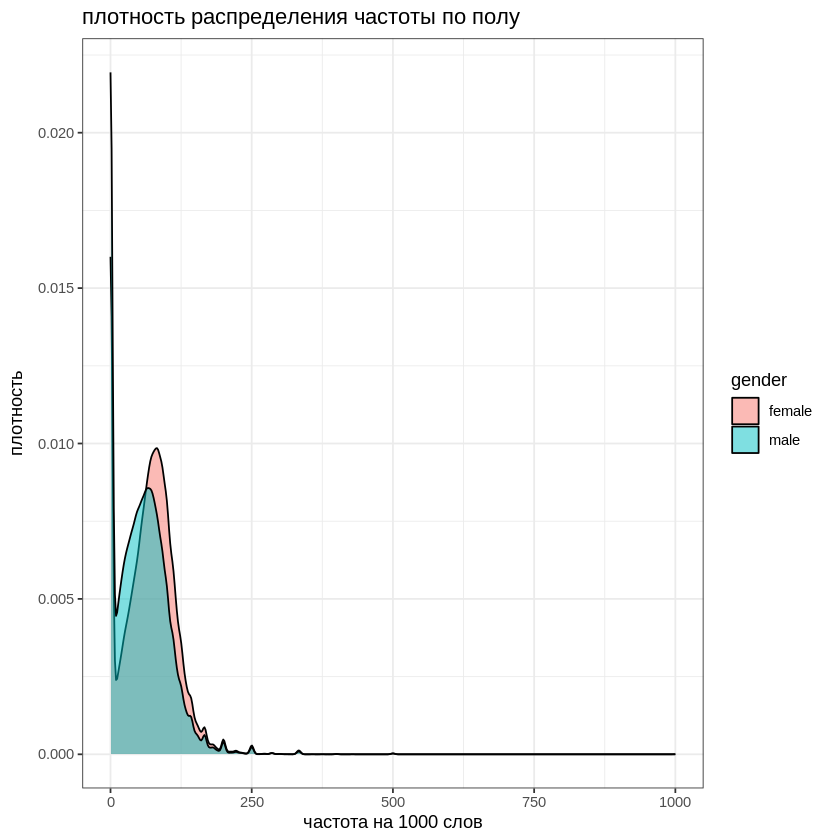

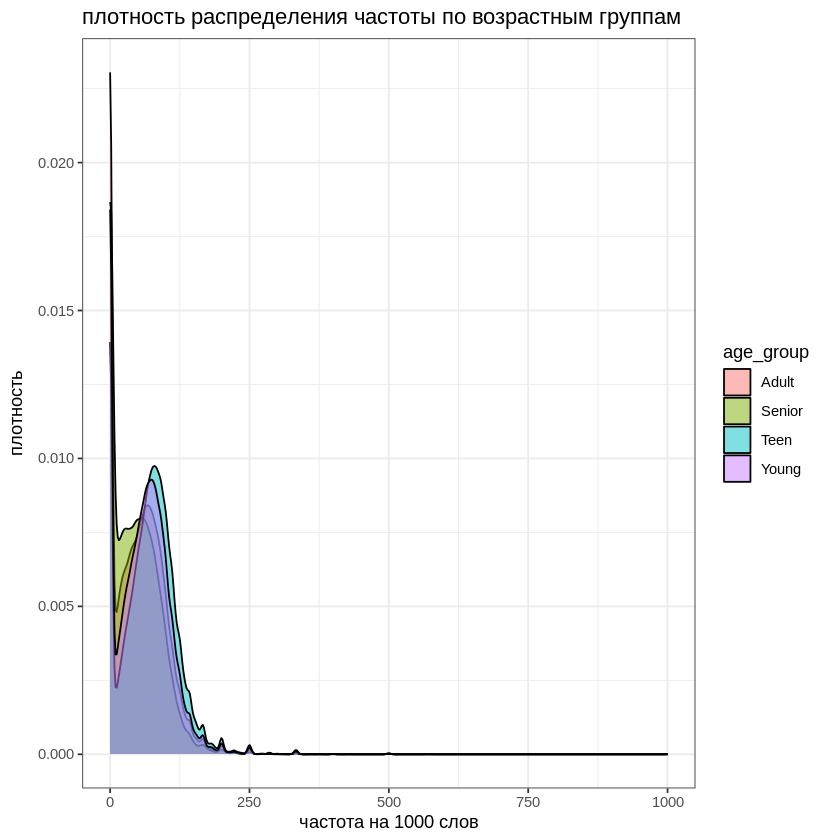

In [ ]:
# Гистограммы плотности (для двух основных факторов)
p_density_gender <- ggplot(data, aes(x = freq_per_1000, fill = gender)) +
  geom_density(alpha = 0.5) +
  labs(title = "плотность распределения частоты по полу", x = "частота на 1000 слов", y = "плотность") +
  theme_bw()
print(p_density_gender)

p_density_age <- ggplot(data, aes(x = freq_per_1000, fill = age_group)) +
  geom_density(alpha = 0.5) +
  labs(title = "плотность распределения частоты по возрастным группам", x = "частота на 1000 слов", y = "плотность") +
  theme_bw()
print(p_density_age)

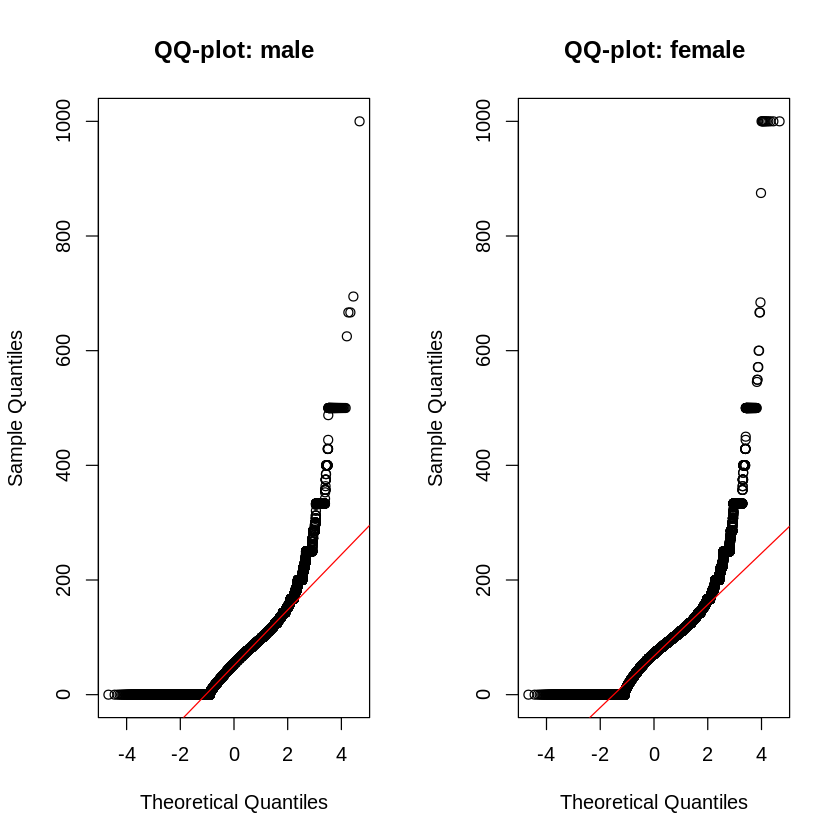

In [ ]:
# 7. Проверка нормальности (QQ-plot)
par(mfrow = c(1, 2))
for (g in unique(data$gender)) {
  subset_data <- data |> filter(gender == g)
  qqnorm(subset_data$freq_per_1000, main = paste("QQ-plot:", g))
  qqline(subset_data$freq_per_1000, col = "red")
}
par(mfrow = c(1, 1))

In [ ]:
# 8. Однофакторные тесты и меры эффекта

# 8.1. Пол (две группы - U-тест Манна-Уитни)
cat("\n=== пол: U-тест Манна-Уитни ===\n")
test_gender <- wilcox.test(freq_per_1000 ~ gender, data = data)
print(test_gender)
# Разница медиан
med_gender <- data |> group_by(gender) |> summarise(med = median(freq_per_1000))
diff_med_gender <- abs(diff(med_gender$med))
cat("разница медиан между группами:", diff_med_gender, "\n")

# 8.2. Возрастная группа (ANOVA)
cat("\n=== возрастная группа: ANOVA ===\n")
aov_age <- aov(freq_per_1000 ~ age_group, data = data)
summary_aov_age <- summary(aov_age)
print(summary_aov_age)
eta_age <- EtaSq(aov_age)[1]
cat("Eta-квадрат для возраста:", eta_age, "\n")

# Tukey HSD
tukey_age <- TukeyHSD(aov_age)
print(tukey_age)

# 8.3. Знак зодиака (ANOVA)
cat("\n=== знак зодиака: ANOVA ===\n")
aov_sign <- aov(freq_per_1000 ~ sign, data = data)
summary_aov_sign <- summary(aov_sign)
print(summary_aov_sign)
eta_sign <- EtaSq(aov_sign)[1]
cat("Eta-квадрат для знака зодиака:", eta_sign, "\n")
tukey_sign <- TukeyHSD(aov_sign)
print(tukey_sign)


=== пол: U-тест Манна-Уитни ===

	Wilcoxon rank sum test with continuity correction

data:  freq_per_1000 by gender
W = 6.8048e+10, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0

разница медиан между группами: 17.444 

=== возрастная группа: ANOVA ===
                Df    Sum Sq  Mean Sq F value Pr(>F)    
age_group        3 4.046e+07 13488161    6425 <2e-16 ***
Residuals   678195 1.424e+09     2099                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
Eta-квадрат для возраста: 0.02763584 
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = freq_per_1000 ~ age_group, data = data)

$age_group
                   diff        lwr       upr p adj
Senior-Adult  -7.700578  -8.479451 -6.921705     0
Teen-Adult    17.537867  17.178997 17.896737     0
Young-Adult    7.489978   7.125189  7.854767     0
Teen-Senior   25.238445  24.466551 26.010340     0
Young-Senior  15.190556  14.415892 

In [ ]:
# 9. Двухфакторный ANOVA с взаимодействием
cat("\n=== двухфакторный ANOVA: пол × возрастная группа ===\n")
aov_gender_age <- aov(freq_per_1000 ~ gender * age_group, data = data)
summary_aov_ga <- summary(aov_gender_age)
print(summary_aov_ga)

cat("\n=== двухфакторный ANOVA: пол × знак зодиака ===\n")
aov_gender_sign <- aov(freq_per_1000 ~ gender * sign, data = data)
summary_aov_gs <- summary(aov_gender_sign)
print(summary_aov_gs)


=== двухфакторный ANOVA: пол × возрастная группа ===
                     Df    Sum Sq  Mean Sq F value Pr(>F)    
gender                1 3.122e+07 31218490   15208 <2e-16 ***
age_group             3 4.024e+07 13412664    6534 <2e-16 ***
gender:age_group      3 6.219e+05   207287     101 <2e-16 ***
Residuals        678191 1.392e+09     2053                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

=== двухфакторный ANOVA: пол × знак зодиака ===
                Df    Sum Sq  Mean Sq  F value Pr(>F)    
gender           1 3.122e+07 31218490 14813.62 <2e-16 ***
sign            11 1.729e+06   157182    74.58 <2e-16 ***
gender:sign     11 2.058e+06   187049    88.76 <2e-16 ***
Residuals   678175 1.429e+09     2107                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


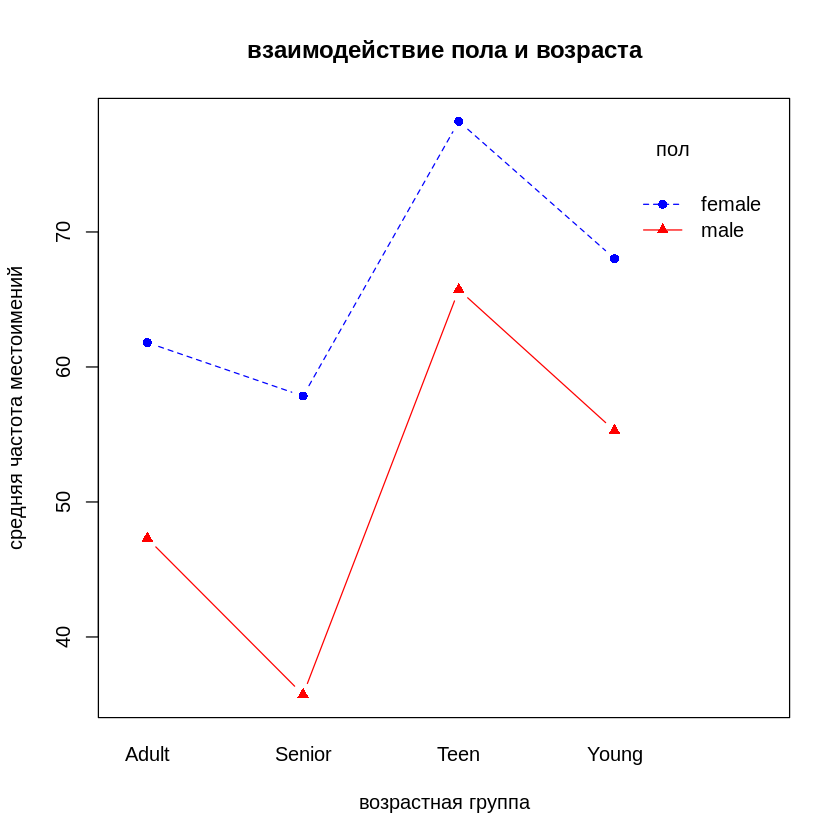

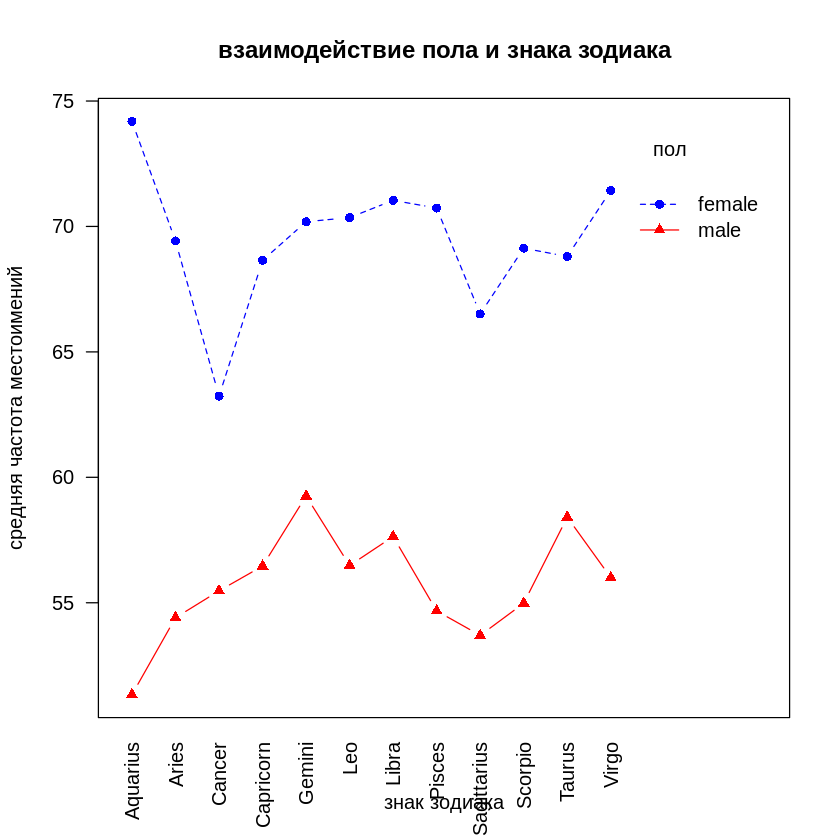

In [ ]:
# 10. Визуализация взаимодействий
# Пол × возраст
interaction.plot(
  x.factor = data$age_group,
  trace.factor = data$gender,
  response = data$freq_per_1000,
  fun = mean,
  type = "b",
  col = c("blue", "red"),
  pch = c(16, 17),
  xlab = "возрастная группа",
  ylab = "средняя частота местоимений",
  trace.label = "пол",
  main = "взаимодействие пола и возраста"
)

# Пол × знак зодиака
interaction.plot(
  x.factor = data$sign,
  trace.factor = data$gender,
  response = data$freq_per_1000,
  fun = mean,
  type = "b",
  col = c("blue", "red"),
  pch = c(16, 17),
  xlab = "знак зодиака",
  ylab = "средняя частота местоимений",
  trace.label = "пол",
  main = "взаимодействие пола и знака зодиака",
  las = 2
)

In [ ]:
# 11. Анализ простых эффектов (если взаимодействие значимо)
# Проверяем, значимо ли взаимодействие пол и возраст
if (summary_aov_ga[[1]][["Pr(>F)"]][3] < 0.05) {
  cat("\n=== взаимодействие пол × возраст значимо. проверяем простые эффекты ===\n")
  age_groups <- unique(data$age_group)
  for (ag in age_groups) {
    subset_data <- data |> filter(age_group == ag)
    if (length(unique(subset_data$gender)) == 2) {
      test <- wilcox.test(freq_per_1000 ~ gender, data = subset_data)
      cat("возрастная группа", ag, ": p-value =", test$p.value,
          ifelse(test$p.value < 0.05, "- значимо", "- не значимо"), "\n")
    }
  }
}

if (summary_aov_gs[[1]][["Pr(>F)"]][3] < 0.05) {
  cat("\n=== взаимодействие пол × знак зодиака значимо. проверяем простые эффекты ===\n")
  signs <- unique(data$sign)
  for (s in signs) {
    subset_data <- data |> filter(sign == s)
    if (length(unique(subset_data$gender)) == 2) {
      test <- wilcox.test(freq_per_1000 ~ gender, data = subset_data)
      cat("знак", s, ": p-value =", test$p.value,
          ifelse(test$p.value < 0.05, "- значимо", "- не значимо"), "\n")
    }
  }
}


=== взаимодействие пол × возраст значимо. проверяем простые эффекты ===
возрастная группа Teen : p-value = 0 - значимо 
возрастная группа Adult : p-value = 0 - значимо 
возрастная группа Young : p-value = 0 - значимо 
возрастная группа Senior : p-value = 0 - значимо 

=== взаимодействие пол × знак зодиака значимо. проверяем простые эффекты ===
знак Leo : p-value = 0 - значимо 
знак Aquarius : p-value = 0 - значимо 
знак Aries : p-value = 0 - значимо 
знак Capricorn : p-value = 0 - значимо 
знак Gemini : p-value = 0 - значимо 
знак Cancer : p-value = 0 - значимо 
знак Sagittarius : p-value = 0 - значимо 
знак Scorpio : p-value = 0 - значимо 
знак Libra : p-value = 0 - значимо 
знак Virgo : p-value = 0 - значимо 
знак Taurus : p-value = 0 - значимо 
знак Pisces : p-value = 0 - значимо 


In [ ]:
# 12. Сравнение эффектов факторов
cat("\n=== сравнение влияния факторов ===\n")
cat("пол: разница медиан =", diff_med_gender, "\n")
cat("возрастная группа: Eta-квадрат =", eta_age, "\n")
cat("знак зодиака: Eta-квадрат =", eta_sign, "\n")

# Выбор фактора с наибольшим эффектом
if (diff_med_gender > eta_age & diff_med_gender > eta_sign) {
  best_factor <- "пол"
} else if (eta_age > eta_sign) {
  best_factor <- "возрастная группа"
} else {
  best_factor <- "знак зодиака"
}
cat("наибольший эффект наблюдается для фактора:", best_factor, "\n")


=== сравнение влияния факторов ===
пол: разница медиан = 17.444 
возрастная группа: Eta-квадрат = 0.02763584 
знак зодиака: Eta-квадрат = 0.001142131 
наибольший эффект наблюдается для фактора: пол 


In [ ]:
# 13. Итоговые выводы
cat("ИТОГОВЫЕ ВЫВОДЫ:\n")
cat("1. Пол: p-value =", test_gender$p.value,
    ifelse(test_gender$p.value < 0.05, " - значимое различие.", " - различие не значимо."), "\n")
cat("2. Возрастная группа: p-value ANOVA =", summary_aov_age[[1]][["Pr(>F)"]][1],
    ifelse(summary_aov_age[[1]][["Pr(>F)"]][1] < 0.05, " - значимые различия.", " - различия не значимы."), "\n")
cat("3. Знак зодиака: p-value ANOVA =", summary_aov_sign[[1]][["Pr(>F)"]][1],
    ifelse(summary_aov_sign[[1]][["Pr(>F)"]][1] < 0.05, " - значимые различия.", " - различия не значимы."), "\n")
if (summary_aov_ga[[1]][["Pr(>F)"]][3] < 0.05) {
  cat("4. Взаимодействие пола и возраста значимо (p =", summary_aov_ga[[1]][["Pr(>F)"]][3], ").\n")
} else {
  cat("4. Взаимодействие пола и возраста не значимо.\n")
}
if (summary_aov_gs[[1]][["Pr(>F)"]][3] < 0.05) {
  cat("5. Взаимодействие пола и знака зодиака значимо (p =", summary_aov_gs[[1]][["Pr(>F)"]][3], ").\n")
} else {
  cat("5. Взаимодействие пола и знака зодиака не значимо.\n")
}
cat("наибольший вклад в объяснение дисперсии вносит фактор:", best_factor, "\n")

ИТОГОВЫЕ ВЫВОДЫ:
1. Пол: p-value = 0  - значимое различие. 
2. Возрастная группа: p-value ANOVA = 0  - значимые различия. 
3. Знак зодиака: p-value ANOVA = 4.351683e-159  - значимые различия. 
4. Взаимодействие пола и возраста значимо (p = 2.367718e-65 ).
5. Взаимодействие пола и знака зодиака значимо (p = 3.350212e-202 ).
наибольший вклад в объяснение дисперсии вносит фактор: пол 


In [ ]:
cor(data$total_words, data$freq_per_1000, method = "spearman")

[1] 0.2117746